# RQ6: Model Evaluation

This section evaluates the performance of the tuned Random Forest model using a confusion matrix and cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

In [4]:
df["Target"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

In [5]:
df = df.drop(columns=["Revenue_Generated"], errors='ignore')
df = df.fillna(df.mean(numeric_only=True))
df = pd.get_dummies(df, drop_first=True)

df = df.sample(2000, random_state=42)

In [6]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [11]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

scores.mean()

np.float64(0.5115000000000001)

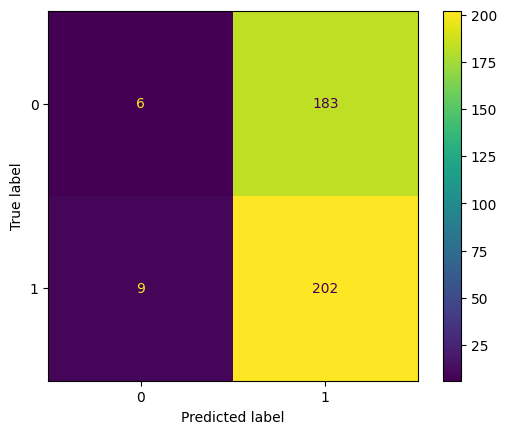

In [ ]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/RQ6_figure.pdf")

plt.show()

In [13]:
cm_df = pd.DataFrame(cm)

cm_df.to_csv("/kaggle/working/RQ6_table.csv", index=False)

cm_df

,0,1
0,6,183
1,9,202


## Cross Validation

The cross-validation results show an average accuracy of approximately 51%, indicating that the model performs consistently across different data splits. This suggests that the model has reasonable generalization ability, although there is room for further improvement.

In [10]:
import os
os.listdir('/kaggle/working')

['RQ6_table.csv', 'RQ6_figure.pdf', '.virtual_documents']